In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import sys
sys.path.append('..')
%load_ext autoreload
%autoreload 2
from utils.helpers import pre_process

dataset = pd.read_csv('../data/train.csv')
train = pre_process(dataset)
test = pd.read_csv('../data/test.csv')
sample_sub = pd.read_csv('../data/sample_submission.csv')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [89]:
dataset['galaxy_population'][:5]

0    Red_Sequence
1    Red_Sequence
2      Blue_Cloud
3    Red_Sequence
4    Red_Sequence
Name: galaxy_population, dtype: object

In [3]:
test.columns

Index(['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
       'spectral_type', 'galaxy_population'],
      dtype='object')

In [4]:
train.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [5]:
train_enc = pre_process(train)

In [6]:
train_enc.head()

,id,alpha,delta,u,g,r,i,z,redshift,galaxy_population,class,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0,0,0,0,1,0
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0,0,0,0,1,0
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,1,1,0,0,0,1
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,0,0,0,0,1,0
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,0,0,0,0,1,0


In [7]:
train_enc.dtypes

id                     int64
alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
galaxy_population      int64
class                  int64
spectral_type_A/F      int64
spectral_type_G/K      int64
spectral_type_M        int64
spectral_type_O/B      int64
dtype: object

In [8]:
train_enc['class'].value_counts()

class
0    377480
1    117143
2     82724
Name: count, dtype: int64

In [9]:
train_enc.describe().T

,count,mean,std,min,25%,50%,75%,max
id,577347.0,288673.000000,166665.867270,0.000000,144336.500000,288673.000000,433009.500000,577346.000000
alpha,577347.0,181.616673,96.242941,0.011684,132.161499,188.681465,231.829693,359.999810
delta,577347.0,21.834654,18.933570,-17.966988,2.474097,21.484412,36.988310,79.158322
u,577347.0,22.441926,2.018135,-0.139225,20.977090,22.570222,23.869103,28.253263
g,577347.0,21.007273,1.795426,13.535483,19.865005,21.467820,22.292715,27.620208
r,577347.0,19.962811,1.648964,12.579407,18.820671,20.431153,21.164096,25.254499
i,577347.0,19.378911,1.580059,11.962781,18.306820,19.631642,20.608191,27.910853
z,577347.0,19.041136,1.584365,11.682803,17.973192,19.188598,20.162111,26.826867
redshift,577347.0,0.723135,0.810070,-0.009970,0.181052,0.497525,0.881390,7.010780
galaxy_population,577347.0,0.446494,0.497129,0.000000,0.000000,0.000000,1.000000,1.000000


In [10]:
train.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [11]:
X_tr = train.drop(columns=['id', 'class'], )
Y_tr = train['class']
X_tr.columns

Index(['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type',
       'galaxy_population'],
      dtype='object')

In [12]:
print("=== SHAPES ===")
print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

=== SHAPES ===
Train: (577347, 12)
Test: (247435, 11)


In [13]:

print("\n=== COLUMNS ===")
print(train.columns.tolist())

print("\n=== DTYPES ===")
print(train.dtypes)



=== COLUMNS ===
['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'class']

=== DTYPES ===
id                     int64
alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
spectral_type         object
galaxy_population     object
class                 object
dtype: object


In [14]:

print("\n=== MISSING VALUES ===")
print(train.isnull().sum())

print("\n=== TARGET DISTRIBUTION ===")
target_col = sample_sub.columns[1]
print(f"Target column: {target_col}")
print(train[target_col].value_counts())
print(train[target_col].value_counts() / train[target_col].count())



=== MISSING VALUES ===
id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64

=== TARGET DISTRIBUTION ===
Target column: class
class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64
class
GALAXY    0.653818
QSO       0.202899
STAR      0.143283
Name: count, dtype: float64


In [15]:
train.iloc[:, 1:].head()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [16]:
train.iloc[:, 1:].describe().T

,count,mean,std,min,25%,50%,75%,max
alpha,577347.0,181.616673,96.242941,0.011684,132.161499,188.681465,231.829693,359.999810
delta,577347.0,21.834654,18.933570,-17.966988,2.474097,21.484412,36.988310,79.158322
u,577347.0,22.441926,2.018135,-0.139225,20.977090,22.570222,23.869103,28.253263
g,577347.0,21.007273,1.795426,13.535483,19.865005,21.467820,22.292715,27.620208
r,577347.0,19.962811,1.648964,12.579407,18.820671,20.431153,21.164096,25.254499
i,577347.0,19.378911,1.580059,11.962781,18.306820,19.631642,20.608191,27.910853
z,577347.0,19.041136,1.584365,11.682803,17.973192,19.188598,20.162111,26.826867
redshift,577347.0,0.723135,0.810070,-0.009970,0.181052,0.497525,0.881390,7.010780


In [17]:
train["spectral_type"].unique()

array(['M', 'O/B', 'G/K', 'A/F'], dtype=object)

In [18]:
train["galaxy_population"].unique()

array(['Red_Sequence', 'Blue_Cloud'], dtype=object)

In [19]:
train["class"].unique()

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

In [20]:
print(train.duplicated().sum())
print(train['id'].duplicated().sum())

0
0


In [21]:
overlap = set(train['id']).intersection(set(test['id']))
# print(f"ID overlap between train and test: {len(overlap)}")
type(len(overlap))
print(len(overlap))

0


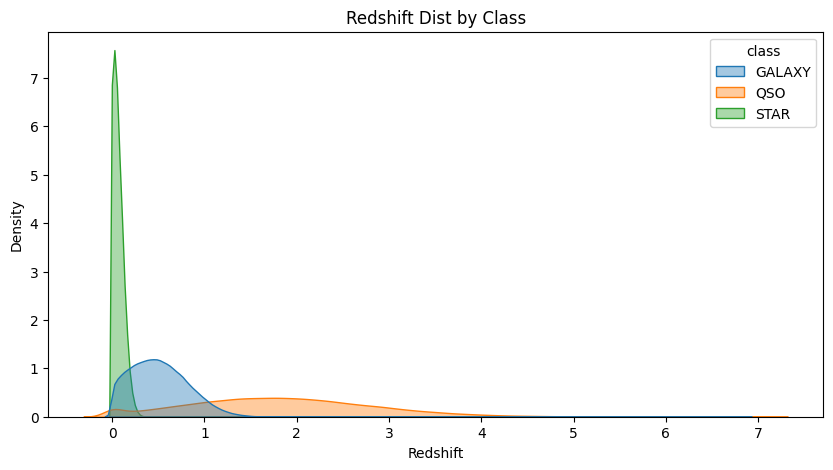

In [22]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=train, x='redshift', hue='class', fill=True, alpha=0.4, common_norm=False)
plt.title('Redshift Dist by Class')
plt.xlabel('Redshift')
plt.show()

In [103]:
train_low_redshift[train_low_redshift['spectral_type_M'] == 1].shape

(120144, 15)

In [97]:
train_low_redshift.columns

Index(['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
       'galaxy_population', 'class', 'spectral_type_A/F', 'spectral_type_G/K',
       'spectral_type_M', 'spectral_type_O/B'],
      dtype='object')

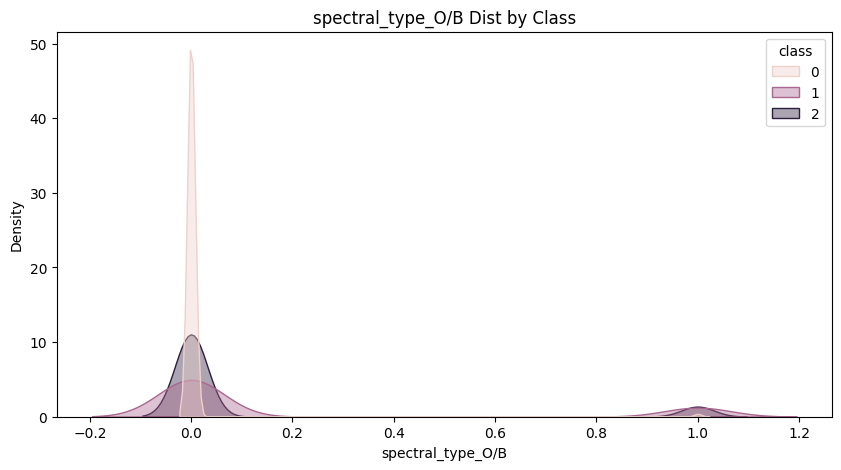

In [95]:
feat = 'spectral_type_O/B'
# data = train 
data = train_low_redshift
plt.figure(figsize=(10, 5))
sns.kdeplot(data=data, x=feat, hue='class', fill=True, alpha=0.4, common_norm=False)
plt.title(f'{feat} Dist by Class')
plt.xlabel(f'{feat}')
plt.show()

In [106]:
train.columns

Index(['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
       'galaxy_population', 'class', 'spectral_type_A/F', 'spectral_type_G/K',
       'spectral_type_M', 'spectral_type_O/B'],
      dtype='object')

In [64]:
train_low_redshift = train[train['redshift'] <= 0.4]
train_low_redshift.shape

(243020, 15)

In [56]:
train[(train['class'] == 2) & (train['redshift'] > 0.39)]['redshift'].count()

np.int64(15)

In [43]:
train_enc['class'].unique(), train['class'].unique()

(array([0, 1, 2]), array(['GALAXY', 'QSO', 'STAR'], dtype=object))

In [44]:
train_enc['class'].value_counts(), train['class'].value_counts()

(class
 0    377480
 1    117143
 2     82724
 Name: count, dtype: int64,
 class
 GALAXY    377480
 QSO       117143
 STAR       82724
 Name: count, dtype: int64)

In [23]:
train.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [24]:
train['spectral_type'].unique()

array(['M', 'O/B', 'G/K', 'A/F'], dtype=object)

In [25]:
train['galaxy_population'].unique()

array(['Red_Sequence', 'Blue_Cloud'], dtype=object)

In [26]:
train['galaxy_population'].map({'Red_Sequence': 0, 'Blue_Cloud': 1}).dtype

dtype('int64')

In [27]:
train.dtypes

id                     int64
alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
spectral_type         object
galaxy_population     object
class                 object
dtype: object

In [28]:
train['class'].unique()

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

In [29]:
train['class'].map({'GALAXY': 0, 'QSO': 1, 'STAR': 2}).value_counts() / train.shape[0]

class
0    0.653818
1    0.202899
2    0.143283
Name: count, dtype: float64

In [30]:
train_enc = pre_process(train)

In [31]:
train_enc.dtypes

id                     int64
alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
galaxy_population      int64
class                  int64
spectral_type_A/F      int64
spectral_type_G/K      int64
spectral_type_M        int64
spectral_type_O/B      int64
dtype: object